In [3]:
from Game.BlackJack import BlackJack
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import random

## 1. Model Evalutation
> In this part, we will test different agents on the environment and compare their performance from different aspects.

### 1.1 Win Rate computation
We will test 10000 games for each agent and calculate the win rate and draw rate.

In [ ]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import random
from Agent.random.randomagent import RandomAgent
from Agent.qlearning.qLearningAgent import qLearningAgent
from Agent.qlearning.newqLearningAgent import newqLearningAgent
from Agent.DQN.dqnwithbet import DQNAgentwithbet,CasinoBlackJack
from Agent.DQN.dqn import DQNAgent
from Game.BlackJack import BlackJack
from Agent.expectimax.expectimaxAgent import ExpectimaxAgent
from Agent.MDP.MDPagent import MDPAgent
from Agent.MDP.MDPagentwithbet import MDPAgentWithBet

In [4]:
simple_agents = [RandomAgent(), ExpectimaxAgent(), MDPAgent(),qLearningAgent(),newqLearningAgent()]
agents_for_win_rate_test = [RandomAgent(), ExpectimaxAgent(), MDPAgent(),qLearningAgent(),newqLearningAgent(),DQNAgent()]
agents_for_casino = [RandomAgent(), ExpectimaxAgent(), MDPAgent(),MDPAgentWithBet(),qLearningAgent(),newqLearningAgent(),DQNAgent()]


In [5]:
rounds = 10000
win_rates = {}
draw_rates = {}
for agent in agents_for_win_rate_test:
    if isinstance(agent, DQNAgentwithbet):
        game_env = CasinoBlackJack(mode="novel")
    else:
        game = BlackJack("novel")
    if isinstance(agent, DQNAgent):
        rounds=100000
    results = {"win": 0, "lose": 0, "draw": 0}
    for i in trange(rounds):
        game.start()
        while game.status == "continue":
            action = agent.choose_action(game)
            game.play(action, "basic")
            if action == "stay" or action == "fold" or action == "switch":
                break
        results[game.game_result()] += 1
        game.reset()
        
    win_rates[agent.__class__.__name__] = results["win"] / rounds

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [01:00<00:00, 1648.39it/s]


{'RandomAgent': 0.5073, 'ExpectimaxAgent': 0.5579, 'MDPAgent': 0.6779, 'qLearningAgent': 0.5713, 'newqLearningAgent': 0.5848, 'DQNAgent': 0.61359}


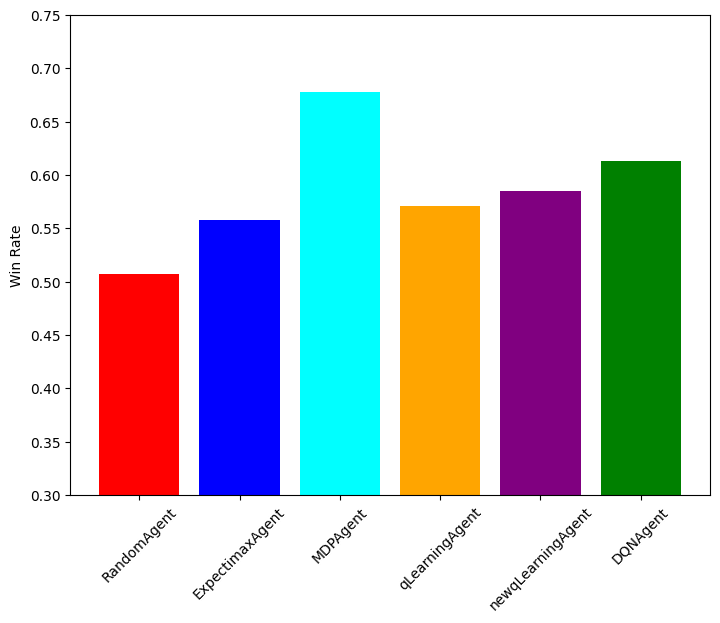

In [7]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
colors = ['red',"blue", 'cyan','orange', 'purple','green']
ax.bar(win_rates.keys(), win_rates.values(), color=colors)
print(win_rates)
ax.set_ylim(0.3, 0.75) 
plt.xticks(rotation=45)
plt.ylabel('Win Rate')
plt.show()

## 1.2 Real Casino Simulation
Since blackjack is a gambling game, we will simulate the real casino environment and test the performance of each agent.We suppose the dealer have $5000000 and the player have $100000 initially and we will test 300 games for each agent. Each time each agent will follow our own bet rule. We will calculate the final money of each agent and compare their performance.

In [18]:
rounds = 300
bet_rounds = {}
final_money = {}
money_history = {}
lose_cnt = 0
win_cnt = 0

def betrule(player_money,dealer_money):
    bet = min(0.1*player_money, 0.1*dealer_money)
    if game.player_hand[1]["number"] == 10 or game.player_hand[0]["number"] == 10:
        bet*=1.5
    if game.dealer_hand[0]["number"] == 10: 
        bet*=0.75
    if win_cnt >=5:
        bet*=1.5
    if lose_cnt >=5:
        bet*=0.5
    return bet*random.choice([1,1.1,0.9])

def basic_betrule(player_money,dealer_money):
    bet = min(0.1*player_money, 0.1*dealer_money)
    return bet
    
for agent in agents_for_casino:
    player_money = 100000
    dealer_money = 5000000
    game = BlackJack("novel")
    money_history[agent.__class__.__name__] = []
    for round_ in trange(rounds):
        game.start()
        bet = betrule(player_money,dealer_money)
        while game.status == "continue":
            action = agent.choose_action(game)
            game.play(action, "basic")
            if action == "stay" or "switch" or "fold":
                break
        if game.game_result() == "win":
            player_money += bet
            dealer_money -= bet
            win_cnt += 1
            lose_cnt=0
        elif game.game_result() == "lose":
            player_money -= bet
            dealer_money += bet
            lose_cnt += 1
            win_cnt=0
        money_history[agent.__class__.__name__].append(player_money)
        if len(game.deck) < 20:
            game.reset()
        if player_money <= 1e-6 or dealer_money <= 1e-6:
            break
    bet_rounds[agent.__class__.__name__] = round_
    final_money[agent.__class__.__name__] = round(player_money)

100%|██████████| 300/300 [00:00<00:00, 1142.62it/s]


In [14]:
bet_rounds, final_money

({'RandomAgent': 299,
  'ExpectimaxAgent': 299,
  'MDPAgent': 299,
  'MDPAgentWithBet': 299,
  'qLearningAgent': 299,
  'newqLearningAgent': 299,
  'DQNAgent': 299},
 {'RandomAgent': 7465,
  'ExpectimaxAgent': 4288148,
  'MDPAgent': 5099884,
  'MDPAgentWithBet': 5092205,
  'qLearningAgent': 5080109,
  'newqLearningAgent': 5093296,
  'DQNAgent': 5099650})

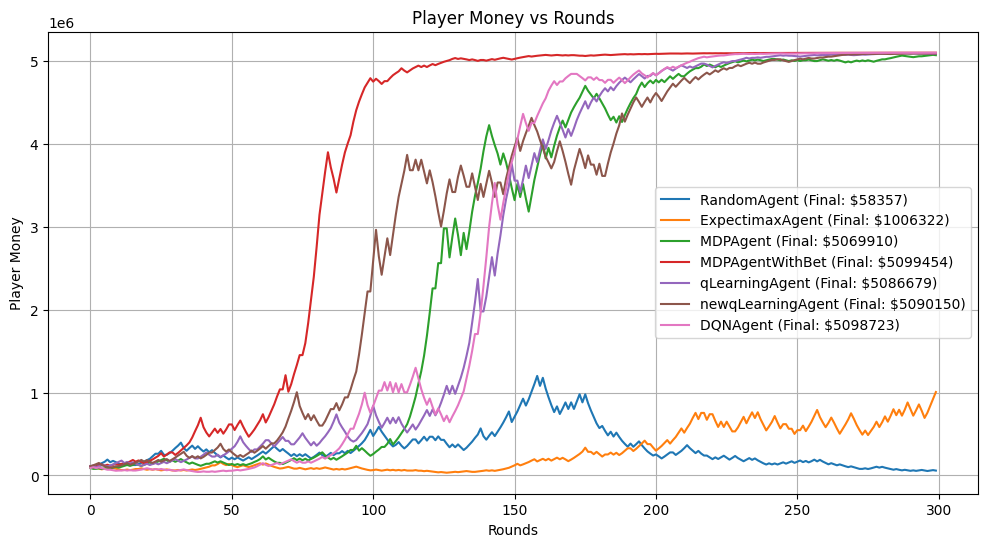

In [19]:
plt.figure(figsize=(12, 6))
for agent_name, history in money_history.items():
    plt.plot(history, label=f"{agent_name} (Final: ${final_money[agent_name]})")

plt.title("Player Money vs Rounds")
plt.xlabel("Rounds")
plt.ylabel("Player Money")
plt.legend()
plt.grid()
plt.show()

In [65]:
rounds = 100  
num_tests = 100  
bet_rounds = {}
final_money = {}
average_money_history = {}  
lose_cnt = 0
win_cnt = 0

for agent in agents_for_casino:
    player_money_init = 10000
    dealer_money_init = 5000000
    money_history = []
    print(f"Testing {agent.__class__.__name__}...")

    for test in trange(num_tests):
        player_money = player_money_init
        dealer_money = dealer_money_init
        game = BlackJack("novel")
        single_run_history = [] 

        for round_ in range(rounds):
            game.start()
            bet = betrule(player_money, dealer_money)

            while game.status == "continue":
                action = agent.choose_action(game)
                game.play(action, "basic")
                if action == "stay" or action == "fold" or action =="switch":
                    break

            if game.game_result() == "win":
                player_money += bet
                dealer_money -= bet
                win_cnt += 1
                lose_cnt = 0
            elif game.game_result() == "lose":
                player_money -= bet
                dealer_money += bet
                lose_cnt += 1
                win_cnt = 0

            single_run_history.append(player_money)  

            if len(game.deck) < 20:
                game.reset()
            if player_money <= 1e-6 or dealer_money <= 1e-6:
                break

        money_history.append(single_run_history)


    max_length = max(len(history) for history in money_history)
    
    ## Ensure that all histories have the same length
    padded_histories = [history + [history[-1]] * (max_length - len(history)) for history in money_history]
    average_money_history[agent.__class__.__name__] = np.mean(padded_histories, axis=0)

Testing RandomAgent...


100%|██████████| 100/100 [00:00<00:00, 965.93it/s]


Testing ExpectimaxAgent...


100%|██████████| 100/100 [00:00<00:00, 539.33it/s]


Testing MDPAgent...


...

100%|██████████| 100/100 [00:00<00:00, 518.02it/s]


Testing qLearningAgent...


100%|██████████| 100/100 [00:00<00:00, 675.93it/s]


Testing DQNAgent...


100%|██████████| 100/100 [00:02<00:00, 39.38it/s]


## 2.5 Q-table's value of traditional q-learning and our advanced q-learning

From this table, we can see that the the action-choose of q-learning is not optimal, it only has three actions: switch,fold and stay. We think it is because that the reward function doesn’t properly encode the strategic value of the four actions. So we build a new q-learning agent with new reward function. Through the second Q-table chart we can find out that the four action all appears in different situations when the agent is advanced q-learning. However, the win rate of the advanced q-learning is not such good and it sometimes cannot converge in the real casino simulate. We will improve it in the later work.

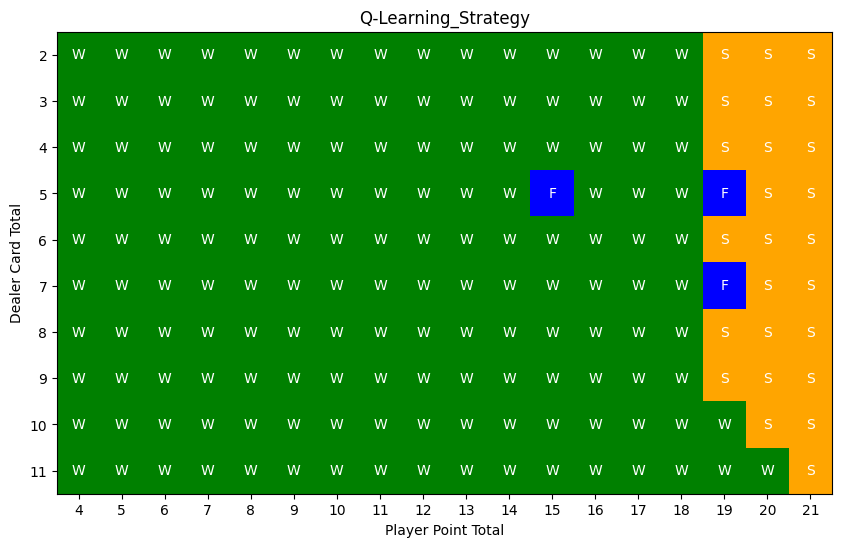

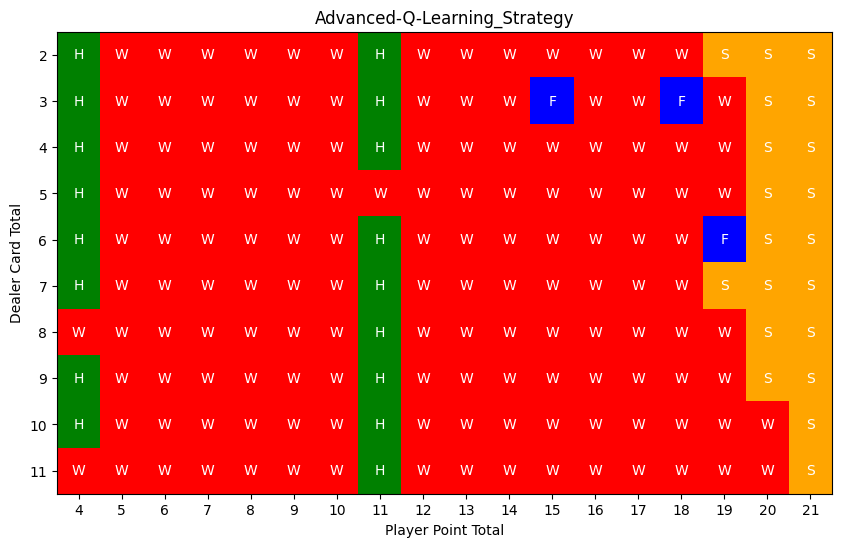

In [7]:
agent = qLearningAgent()
Q1 = agent.Q
agent2 = newqLearningAgent()
Q2 = agent2.Q
player_points = range(4, 22)  
dealer_points = range(2, 12)  
strategy = np.empty((len(dealer_points), len(player_points)), dtype=str)

def extract_strategy(Q, usable_ace):
    strategy = np.empty((len(dealer_points), len(player_points)), dtype=str)
    for i, dealer in enumerate(dealer_points):
        for j, player in enumerate(player_points):
            state_Q_values = Q[player, dealer, usable_ace, :] 
            best_action = np.argmax(state_Q_values) 
            if best_action == 0:
                strategy[i, j] = 'H'
            elif best_action == 1:
                strategy[i, j] = 'W'  
            elif best_action == 2:
                strategy[i, j] = 'F'  
            elif best_action == 3:
                strategy[i, j] = 'S' 
    return strategy


def plot_strategy(strategy, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    cmap = {'H': 0, 'W':1, 'F':2,'S': 3}
    numeric_matrix = np.vectorize(cmap.get)(strategy) 
   
    colors = ['green', 'red','blue','orange'] 
    colormap = plt.matplotlib.colors.ListedColormap(colors)

    im = ax.imshow(numeric_matrix, aspect='auto', cmap=colormap)

  
    for i in range(len(dealer_points)):
        for j in range(len(player_points)):
            action = strategy[i, j]
            ax.text(j, i, action, ha='center', va='center', color='white')

    ax.set_xticks(np.arange(len(player_points)))
    ax.set_yticks(np.arange(len(dealer_points)))
    ax.set_xticklabels(player_points)
    ax.set_yticklabels(dealer_points)
    ax.set_xlabel("Player Point Total")
    ax.set_ylabel("Dealer Card Total")
    ax.set_title(title)
    plt.show()
strategy = extract_strategy(Q1, usable_ace=0) 
plot_strategy(strategy, "Q-Learning_Strategy")
strategy = extract_strategy(Q2, usable_ace=0) 
plot_strategy(strategy, "Advanced-Q-Learning_Strategy")